# 🛒 High-Value Purchase Prediction
### Hackathon ML Pipeline — End-to-End
**Dataset:** `hackathon_dataset.csv` &nbsp;|&nbsp; **Target:** `high_value_purchase` (0 / 1)  
**Metric:** F1-Score (primary) · ROC-AUC · Precision · Recall

## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (f1_score, roc_auc_score, precision_score,
                              recall_score, classification_report,
                              confusion_matrix, roc_curve)

SEED = 42
np.random.seed(SEED)
%matplotlib inline
print("✅ Libraries loaded")

✅ Libraries loaded


## 2. Load Dataset

In [2]:
# ⚠️  Update this path if your CSV is in a different location
DATA_PATH = "hackathon_dataset.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nTarget balance:")
print(df["high_value_purchase"].value_counts())
df.head()

Shape: (5000, 16)

Target balance:
high_value_purchase
1    2500
0    2500
Name: count, dtype: int64


,customer_id,age,account_age_months,total_purchases,avg_order_value,days_since_last_purchase,cart_abandonment_rate,product_reviews_count,avg_review_rating,email_opens,bounce_rate,customer_segment,device_type,country,has_promo_code,high_value_purchase
0,1,40,3,8,144.803991,19.0,0.448209,5,4.730586,6,0.066779,Platinum,Desktop,Germany,1,1
1,2,33,4,6,135.230774,14.0,0.748136,6,4.442075,6,0.009125,Platinum,Tablet,Canada,0,1
2,3,42,12,9,127.489297,29.0,0.277773,2,2.851251,7,0.215691,Bronze,Mobile,USA,0,0
3,4,53,6,13,103.274929,19.0,0.172000,1,NaN,8,0.216097,Bronze,Mobile,Germany,0,0
4,5,32,5,9,135.392030,36.0,0.702960,4,4.204663,5,0.358715,Silver,Mobile,UK,1,1


### 2.1 Data Info & Missing Values

In [3]:
print("=== dtypes ===")
print(df.dtypes)
print("\n=== Missing values ===")
print(df.isnull().sum())
print("\n=== Basic stats ===")
df.describe()

=== dtypes ===
customer_id                   int64
age                           int64
account_age_months            int64
total_purchases               int64
avg_order_value             float64
days_since_last_purchase    float64
cart_abandonment_rate       float64
product_reviews_count         int64
avg_review_rating           float64
email_opens                   int64
bounce_rate                 float64
customer_segment             object
device_type                  object
country                      object
has_promo_code                int64
high_value_purchase           int64
dtype: object

=== Missing values ===
customer_id                   0
age                           0
account_age_months            0
total_purchases               0
avg_order_value               0
days_since_last_purchase    150
cart_abandonment_rate         0
product_reviews_count         0
avg_review_rating           250
email_opens                   0
bounce_rate                   0
customer_segment   

,customer_id,age,account_age_months,total_purchases,avg_order_value,days_since_last_purchase,cart_abandonment_rate,product_reviews_count,avg_review_rating,email_opens,bounce_rate,has_promo_code,high_value_purchase
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,4850.000000,5000.000000,5000.000000,4750.000000,5000.000000,5000.000000,5000.000000,5000.00000
mean,2500.500000,34.752800,18.886000,8.01800,183.378192,28.903505,0.501887,2.977400,2.978426,4.958600,0.287282,0.310000,0.50000
std,1443.520003,13.174369,18.976845,2.84459,292.326538,28.878440,0.285574,1.716822,1.152886,2.239707,0.160831,0.462539,0.50005
min,1.000000,-5.000000,0.000000,0.00000,1.740569,0.000000,0.000171,0.000000,1.000117,0.000000,0.002162,0.000000,0.00000
25%,1250.750000,27.000000,5.000000,6.00000,40.336029,8.000000,0.258820,2.000000,1.957422,3.000000,0.159115,0.000000,0.00000
50%,2500.500000,35.000000,13.000000,8.00000,90.052653,20.000000,0.500070,3.000000,2.997302,5.000000,0.267182,0.000000,0.50000
75%,3750.250000,43.000000,26.000000,10.00000,204.310611,41.000000,0.748924,4.000000,3.965156,6.000000,0.391408,1.000000,1.00000
max,5000.000000,200.000000,160.000000,20.00000,5201.682380,236.000000,0.999875,10.000000,4.998368,20.000000,0.887301,1.000000,1.00000


## 3. Exploratory Data Analysis (EDA)

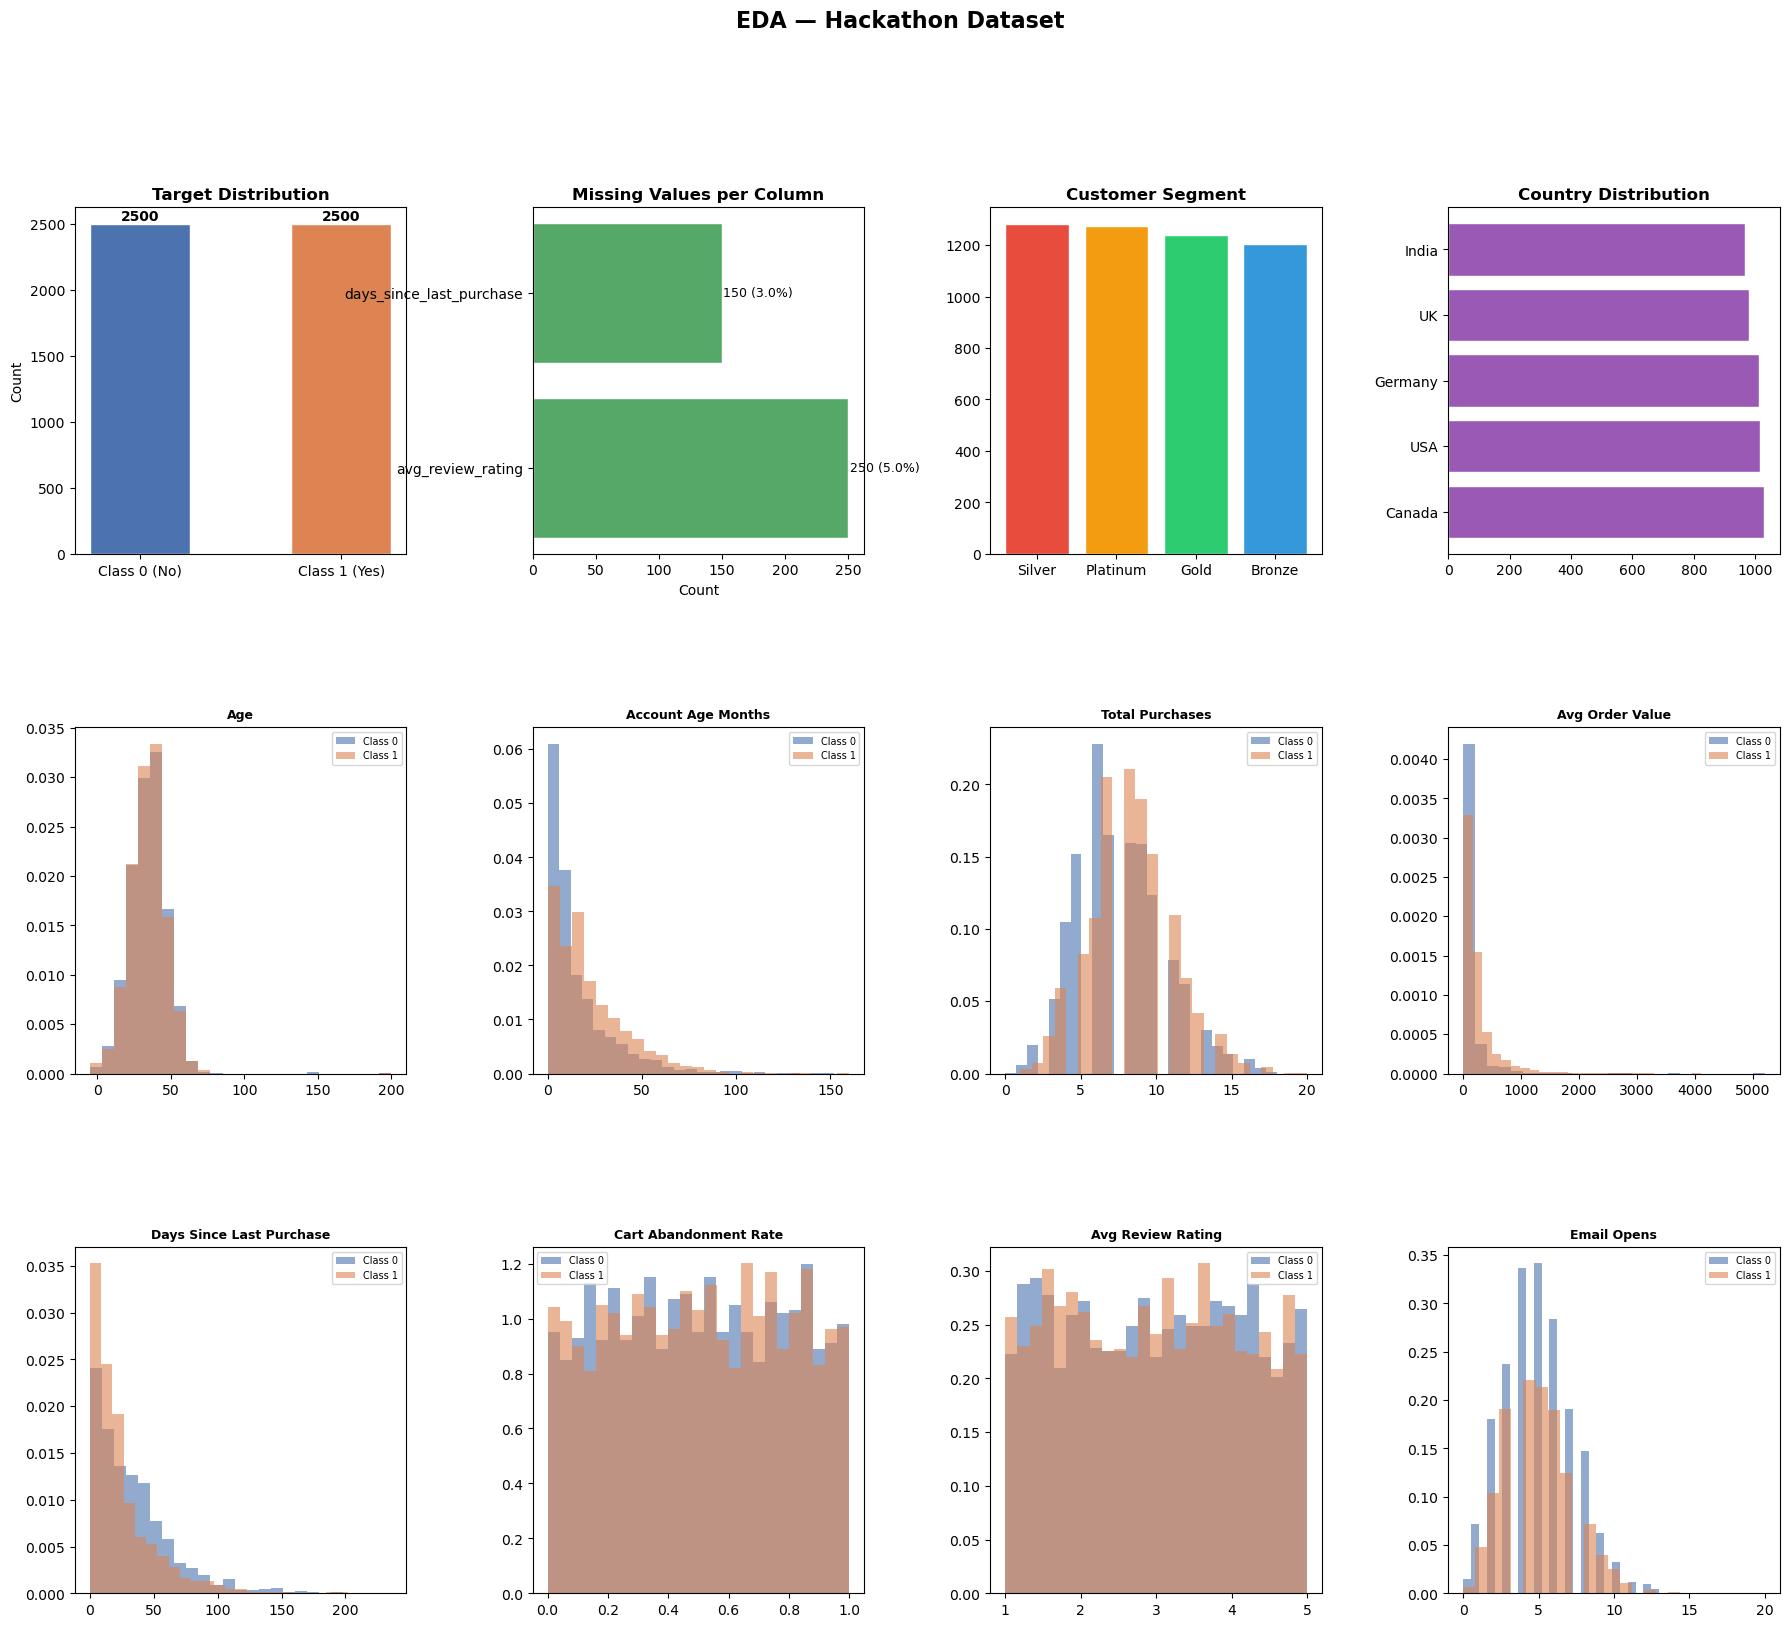

✅ EDA complete


In [4]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle("EDA — Hackathon Dataset", fontsize=16, fontweight="bold", y=0.99)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.38)

num_cols = ["age", "account_age_months", "total_purchases", "avg_order_value",
            "days_since_last_purchase", "cart_abandonment_rate",
            "avg_review_rating", "email_opens"]

# Target distribution
ax0 = fig.add_subplot(gs[0, 0])
counts = df["high_value_purchase"].value_counts()
bars = ax0.bar(["Class 0 (No)", "Class 1 (Yes)"], counts,
               color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
ax0.set_title("Target Distribution", fontweight="bold")
ax0.set_ylabel("Count")
for b, v in zip(bars, counts):
    ax0.text(b.get_x() + b.get_width()/2, v + 30, str(v), ha="center", fontweight="bold")

# Missing values
ax1 = fig.add_subplot(gs[0, 1])
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
ax1.barh(missing.index, missing.values, color="#55A868", edgecolor="white")
ax1.set_title("Missing Values per Column", fontweight="bold")
ax1.set_xlabel("Count")
for i, v in enumerate(missing.values):
    ax1.text(v + 1, i, f"{v} ({v/len(df)*100:.1f}%)", va="center", fontsize=9)

# Customer segment
ax2 = fig.add_subplot(gs[0, 2])
seg = df["customer_segment"].value_counts()
ax2.bar(seg.index, seg.values, color=["#e74c3c","#f39c12","#2ecc71","#3498db"], edgecolor="white")
ax2.set_title("Customer Segment", fontweight="bold")

# Country
ax3 = fig.add_subplot(gs[0, 3])
cntry = df["country"].value_counts()
ax3.barh(cntry.index, cntry.values, color="#9b59b6", edgecolor="white")
ax3.set_title("Country Distribution", fontweight="bold")

# Numeric distributions by class
plot_positions = [(1,0),(1,1),(1,2),(1,3),(2,0),(2,1),(2,2),(2,3)]
for (r, c), col in zip(plot_positions, num_cols):
    ax = fig.add_subplot(gs[r, c])
    for cls, color, label in zip([0, 1], ["#4C72B0", "#DD8452"], ["Class 0", "Class 1"]):
        data = df[df["high_value_purchase"] == cls][col].dropna()
        ax.hist(data, bins=25, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col.replace("_", " ").title(), fontsize=9, fontweight="bold")
    ax.legend(fontsize=7)

plt.savefig("eda.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ EDA complete")

### 3.1 Correlation Heatmap

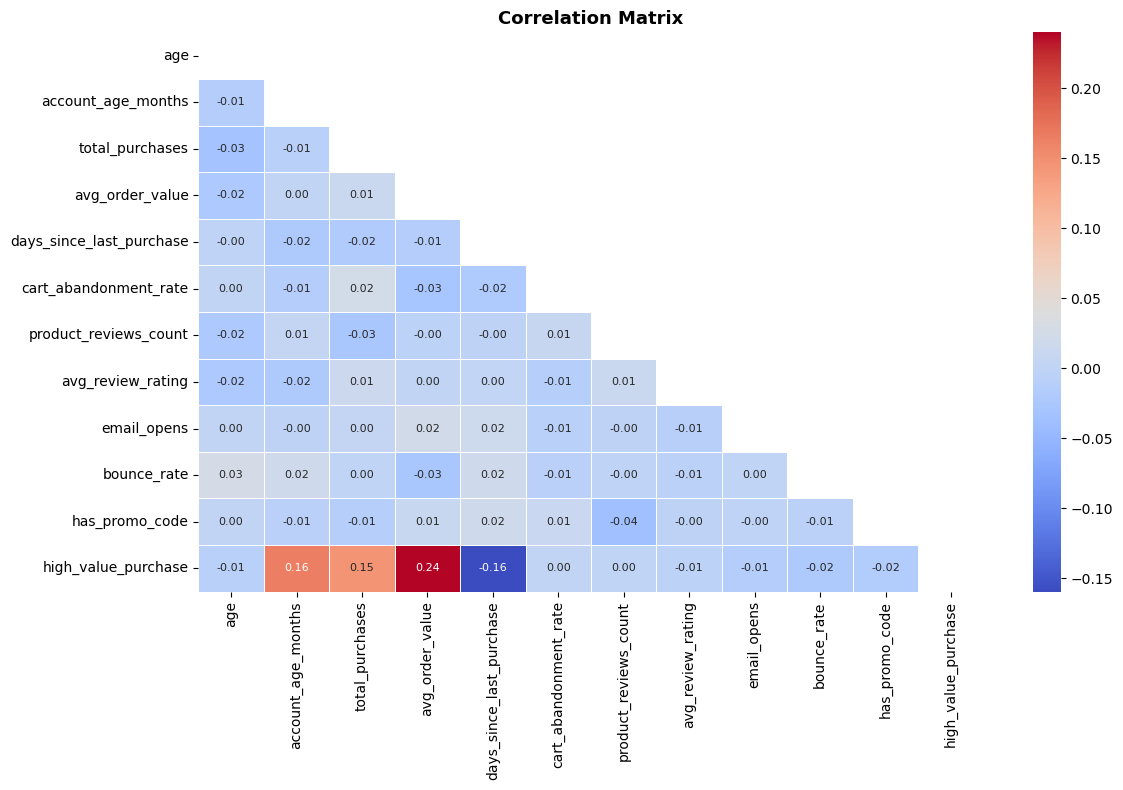

In [5]:
plt.figure(figsize=(12, 8))
num_only = df.select_dtypes(include=np.number).drop(columns=["customer_id"])
corr = num_only.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Correlation Matrix", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Data Cleaning

In [10]:
df_c = df.copy()

# 4.1 Drop customer_id
df_c = df_c.drop(columns=["customer_id"])
print("✅ Dropped customer_id")

# 4.2 Fix invalid ages
invalid_age = (df_c["age"] < 0) | (df_c["age"] > 100)
print(f"\n4.2 Invalid age rows: {invalid_age.sum()}")
df_c.loc[invalid_age, "age"] = np.nan
df_c["age"] = df_c["age"].fillna(df_c["age"].median())

# 4.3 Cap outliers at 99th percentile
cap_cols = ["avg_order_value", "account_age_months", "days_since_last_purchase"]
for col in cap_cols:
    q99 = df_c[col].quantile(0.99)
    n   = (df_c[col] > q99).sum()
    df_c[col] = df_c[col].clip(upper=q99)
    print(f"4.3 Capped {n} outliers in '{col}' at {q99:.1f}")

# 4.4 Median impute missing values
df_c["days_since_last_purchase"] = df_c["days_since_last_purchase"].fillna(
    df_c["days_since_last_purchase"].median())
df_c["avg_review_rating"] = df_c["avg_review_rating"].fillna(
    df_c["avg_review_rating"].median())
print(f"\n4.4 Imputed missing values")
print(f"    Remaining nulls: {df_c.isnull().sum().sum()}")

# 4.5 Encode customer_segment (ordinal)
seg_order = ["Bronze", "Silver", "Gold", "Platinum"]
df_c["segment_rank"] = df_c["customer_segment"].map({s: i for i, s in enumerate(seg_order)})
print("\n4.5 Ordinal encoded: segment_rank →", dict(enumerate(seg_order)))

# 4.6 One-hot encode device_type & country
df_c = pd.get_dummies(df_c, columns=["device_type", "country"], drop_first=True)
df_c = df_c.drop(columns=["customer_segment"])
print(f"\n4.6 One-hot encoded device_type & country")
print(f"\n✅ Cleaned shape: {df_c.shape}")
df_c.head()

✅ Dropped customer_id

4.2 Invalid age rows: 15
4.3 Capped 50 outliers in 'avg_order_value' at 1424.0
4.3 Capped 46 outliers in 'account_age_months' at 85.0
4.3 Capped 47 outliers in 'days_since_last_purchase' at 139.0

4.4 Imputed missing values
    Remaining nulls: 0

4.5 Ordinal encoded: segment_rank → {0: 'Bronze', 1: 'Silver', 2: 'Gold', 3: 'Platinum'}

4.6 One-hot encoded device_type & country

✅ Cleaned shape: (5000, 19)


,age,account_age_months,total_purchases,avg_order_value,days_since_last_purchase,cart_abandonment_rate,product_reviews_count,avg_review_rating,email_opens,bounce_rate,has_promo_code,high_value_purchase,segment_rank,device_type_Mobile,device_type_Tablet,country_Germany,country_India,country_UK,country_USA
0,40.0,3,8,144.803991,19.0,0.448209,5,4.730586,6,0.066779,1,1,3,False,False,True,False,False,False
1,33.0,4,6,135.230774,14.0,0.748136,6,4.442075,6,0.009125,0,1,3,False,True,False,False,False,False
2,42.0,12,9,127.489297,29.0,0.277773,2,2.851251,7,0.215691,0,0,0,True,False,False,False,False,True
3,53.0,6,13,103.274929,19.0,0.172000,1,2.997302,8,0.216097,0,0,0,True,False,True,False,False,False
4,32.0,5,9,135.392030,36.0,0.702960,4,4.204663,5,0.358715,1,1,1,True,False,False,False,True,False


## 5. Feature Engineering

In [11]:
df_f = df_c.copy()

# Engagement: email opens + reviews - bounce penalty
df_f["engagement_score"]    = (df_f["email_opens"] * 0.4 +
                                df_f["product_reviews_count"] * 0.3 -
                                df_f["bounce_rate"] * 10 * 0.3)

# Purchase velocity: how often they buy relative to account age
df_f["purchase_velocity"]   = df_f["total_purchases"] / (df_f["account_age_months"] + 1)

# Intent: active purchasers who don't abandon carts
df_f["intent_score"]        = df_f["total_purchases"] * (1 - df_f["cart_abandonment_rate"])

# Loyalty × recency: loyal but also recently active
df_f["loyalty_recency"]     = df_f["account_age_months"] / (df_f["days_since_last_purchase"] + 1)

# Log-transform for right-skewed order values
df_f["log_avg_order_value"] = np.log1p(df_f["avg_order_value"])

# Review quality: rating weighted by volume of reviews
df_f["review_quality"]      = df_f["avg_review_rating"] * np.log1p(df_f["product_reviews_count"])

# Promo-sensitive: used promo AND is a frequent buyer
df_f["promo_buyer"]         = ((df_f["has_promo_code"] == 1) &
                                (df_f["total_purchases"] > 8)).astype(int)

# VIP spender: high-tier segment AND above-average order value
df_f["vip_spender"]         = ((df_f["segment_rank"] >= 2) &
                                (df_f["avg_order_value"] > 150)).astype(int)

print(f"✅ Feature engineering complete")
print(f"   Raw features  : {df.shape[1] - 1}")
print(f"   Final features: {df_f.shape[1] - 1}")
df_f.head()

✅ Feature engineering complete
   Raw features  : 15
   Final features: 26


,age,account_age_months,total_purchases,avg_order_value,days_since_last_purchase,cart_abandonment_rate,product_reviews_count,avg_review_rating,email_opens,bounce_rate,...,country_UK,country_USA,engagement_score,purchase_velocity,intent_score,loyalty_recency,log_avg_order_value,review_quality,promo_buyer,vip_spender
0,40.0,3,8,144.803991,19.0,0.448209,5,4.730586,6,0.066779,...,False,False,3.699662,2.000000,4.414327,0.150000,4.982263,8.476072,0,0
1,33.0,4,6,135.230774,14.0,0.748136,6,4.442075,6,0.009125,...,False,False,4.172624,1.200000,1.511181,0.266667,4.914350,8.643879,0,0
2,42.0,12,9,127.489297,29.0,0.277773,2,2.851251,7,0.215691,...,False,True,2.752928,0.692308,6.500044,0.400000,4.855846,3.132419,0,0
3,53.0,6,13,103.274929,19.0,0.172000,1,2.997302,8,0.216097,...,False,False,2.851708,1.857143,10.764006,0.300000,4.647031,2.077572,0,0
4,32.0,5,9,135.392030,36.0,0.702960,4,4.204663,5,0.358715,...,True,False,2.123854,1.500000,2.673362,0.135135,4.915533,6.767144,1,0


## 6. Train / Test Split

In [12]:
TARGET = "high_value_purchase"
X = df_f.drop(columns=[TARGET])
y = df_f[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_train)
X_te_sc  = scaler.transform(X_test)

print(f"Train : {len(X_train)} rows ({y_train.mean()*100:.1f}% positive)")
print(f"Test  : {len(X_test)}  rows ({y_test.mean()*100:.1f}% positive)")
print(f"Features: {X.shape[1]}")

Train : 4000 rows (50.0% positive)
Test  : 1000  rows (50.0% positive)
Features: 26


## 7. Model Training & Cross-Validation

In [13]:
models = {
    "Logistic Regression": LogisticRegression(C=1.0, max_iter=1000, random_state=SEED),
    "Decision Tree":        DecisionTreeClassifier(max_depth=7, min_samples_leaf=20, random_state=SEED),
    "Random Forest":        RandomForestClassifier(n_estimators=300, max_depth=10,
                                                    min_samples_leaf=10, random_state=SEED),
    "Gradient Boosting":    GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                                        max_depth=4, subsample=0.8, random_state=SEED),
    "AdaBoost":             AdaBoostClassifier(n_estimators=200, learning_rate=0.5, random_state=SEED),
    "KNN":                  KNeighborsClassifier(n_neighbors=9, weights="distance"),
    "SVM (RBF)":            SVC(kernel="rbf", C=1.0, probability=True, random_state=SEED),
}

SCALED = {"Logistic Regression", "KNN", "SVM (RBF)"}
cv5    = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

print(f"{'Model':<22} {'CV-F1':>8} {'F1':>8} {'AUC':>8} {'Prec':>8} {'Rec':>8}")
print("="*68)

for name, mdl in models.items():
    Xtr = X_tr_sc if name in SCALED else X_train
    Xte = X_te_sc if name in SCALED else X_test

    cv_f1 = cross_val_score(mdl, Xtr, y_train, cv=cv5, scoring="f1").mean()
    mdl.fit(Xtr, y_train)
    y_pred = mdl.predict(Xte)
    y_prob = mdl.predict_proba(Xte)[:, 1]

    results[name] = dict(
        model=mdl, use_scaled=(name in SCALED),
        cv_f1=cv_f1,
        f1=f1_score(y_test, y_pred),
        auc=roc_auc_score(y_test, y_prob),
        precision=precision_score(y_test, y_pred),
        recall=recall_score(y_test, y_pred),
        y_pred=y_pred, y_prob=y_prob,
    )
    r = results[name]
    print(f"{name:<22} {cv_f1:>8.4f} {r['f1']:>8.4f} {r['auc']:>8.4f} "
          f"{r['precision']:>8.4f} {r['recall']:>8.4f}")

print("="*68)
best_name = max(results, key=lambda k: results[k]["f1"])
best      = results[best_name]
print(f"\n🏆  Best model : {best_name}")
print(f"    F1-Score   : {best['f1']:.4f}")
print(f"    ROC-AUC    : {best['auc']:.4f}")

Model                     CV-F1       F1      AUC     Prec      Rec
Logistic Regression      0.7541   0.7685   0.8466   0.7771   0.7600
Decision Tree            0.7949   0.7727   0.8762   0.8284   0.7240
Random Forest            0.8117   0.7988   0.8965   0.8252   0.7740
Gradient Boosting        0.8135   0.7955   0.8972   0.8182   0.7740
AdaBoost                 0.8175   0.8183   0.9057   0.8309   0.8060
KNN                      0.6656   0.6371   0.7400   0.6741   0.6040
SVM (RBF)                0.7452   0.7508   0.8329   0.7705   0.7320

🏆  Best model : AdaBoost
    F1-Score   : 0.8183
    ROC-AUC    : 0.9057


## 8. Best Model — Classification Report

In [14]:
print(f"Model: {best_name}\n")
print(classification_report(y_test, best["y_pred"],
                             target_names=["No Purchase", "High-Value"]))

Model: AdaBoost

              precision    recall  f1-score   support

 No Purchase       0.81      0.84      0.82       500
  High-Value       0.83      0.81      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



## 9. Evaluation Dashboard

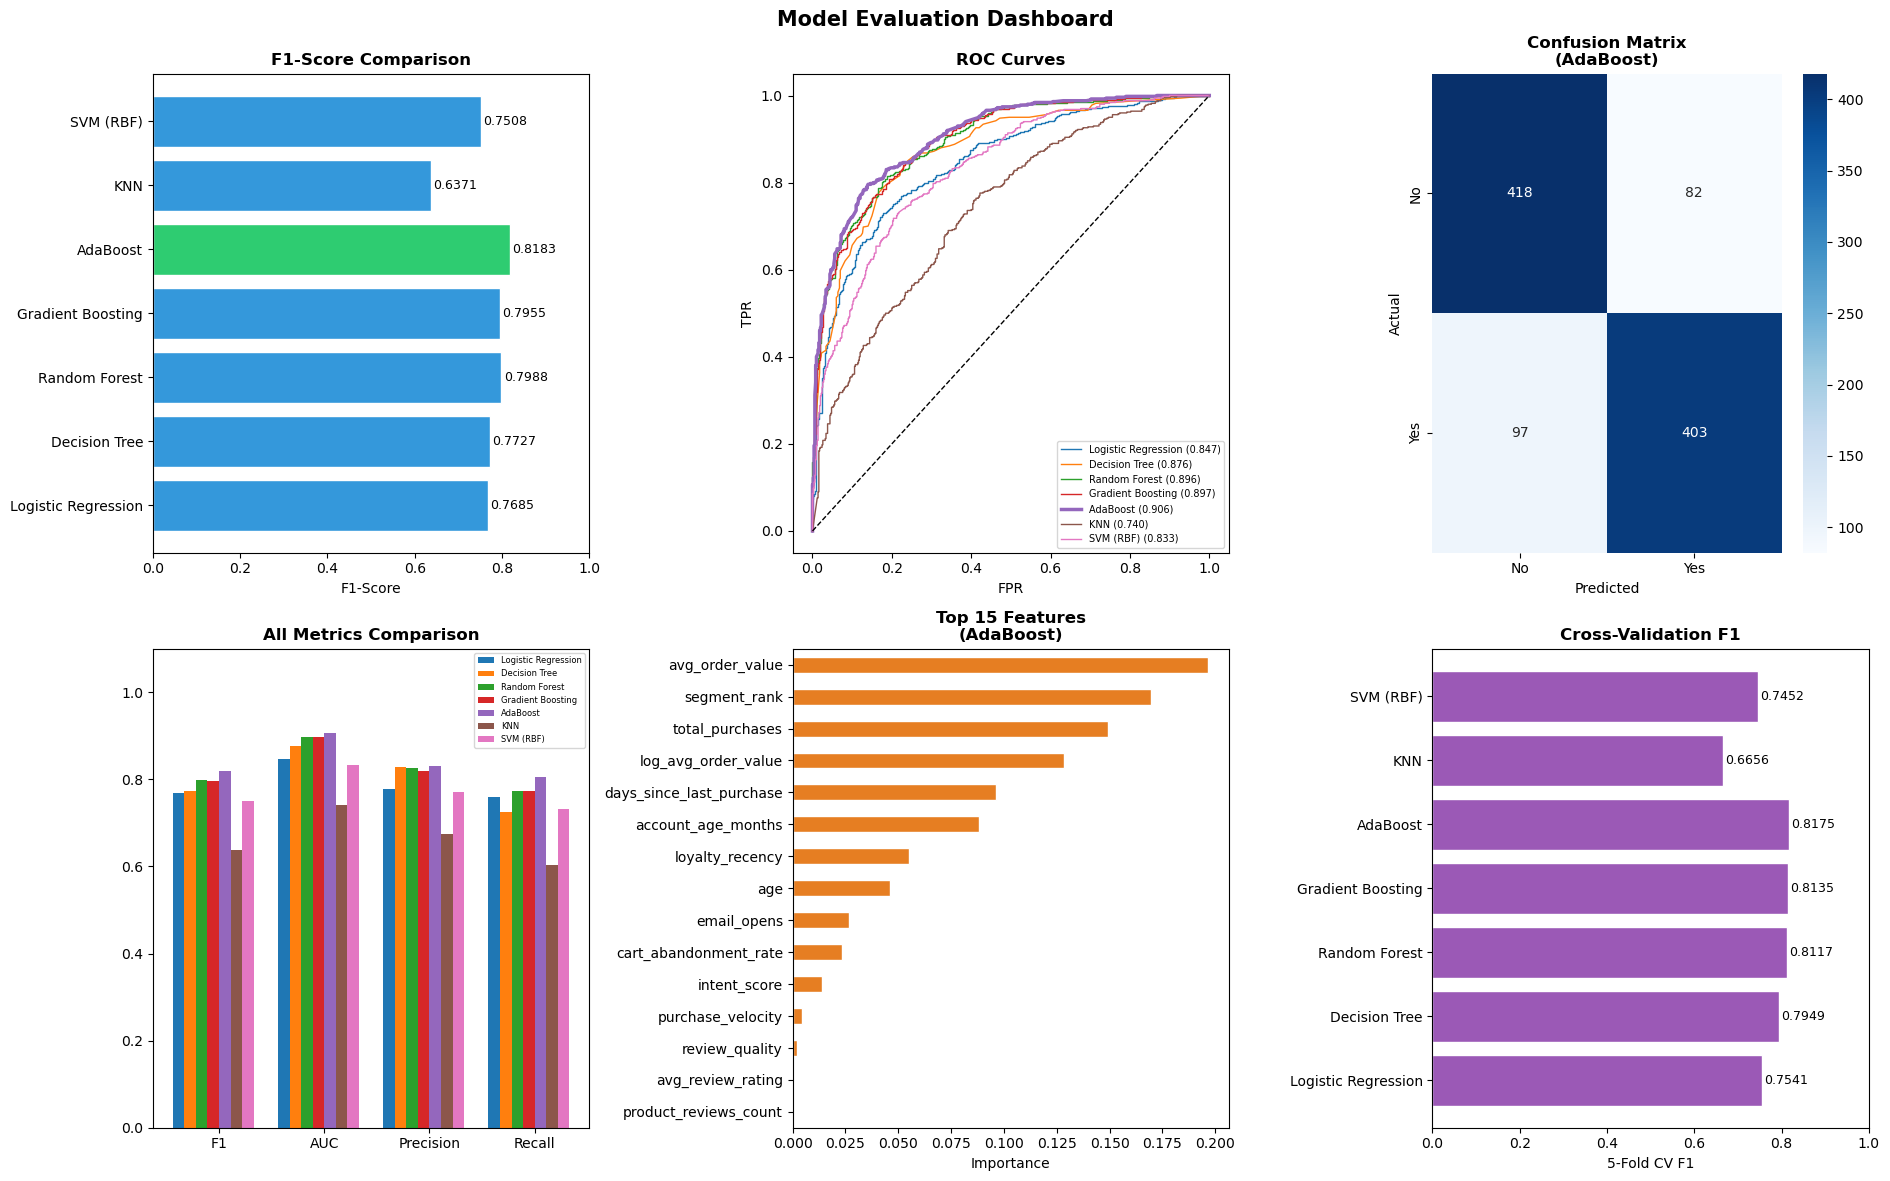

✅ Dashboard saved as evaluation_dashboard.png


In [15]:
names  = list(results.keys())
colors = ["#2ecc71" if n == best_name else "#3498db" for n in names]
fig2, axes = plt.subplots(2, 3, figsize=(19, 12))
fig2.suptitle("Model Evaluation Dashboard", fontsize=15, fontweight="bold")

# F1 bar
ax = axes[0, 0]
f1s  = [results[n]["f1"] for n in names]
bars = ax.barh(names, f1s, color=colors, edgecolor="white")
ax.set_xlabel("F1-Score"); ax.set_title("F1-Score Comparison", fontweight="bold")
ax.set_xlim(0, 1)
for b, v in zip(bars, f1s):
    ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.4f}", va="center", fontsize=9)

# ROC curves
ax = axes[0, 1]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, lw=2.5 if name==best_name else 1,
            label=f"{name} ({res['auc']:.3f})")
ax.plot([0,1],[0,1],"k--",lw=1)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curves", fontweight="bold")
ax.legend(fontsize=7, loc="lower right")

# Confusion matrix
ax = axes[0, 2]
cm = confusion_matrix(y_test, best["y_pred"])
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No","Yes"], yticklabels=["No","Yes"])
ax.set_title(f"Confusion Matrix\n({best_name})", fontweight="bold")
ax.set_ylabel("Actual"); ax.set_xlabel("Predicted")

# Grouped metrics
ax = axes[1, 0]
metric_names = ["F1","AUC","Precision","Recall"]
x = np.arange(len(metric_names)); w = 0.11
for i, (name, res) in enumerate(results.items()):
    ax.bar(x+i*w, [res["f1"],res["auc"],res["precision"],res["recall"]], w, label=name)
ax.set_xticks(x + w*len(results)/2)
ax.set_xticklabels(metric_names)
ax.set_ylim(0, 1.1); ax.set_title("All Metrics Comparison", fontweight="bold")
ax.legend(fontsize=6)

# Feature importance (best tree)
ax = axes[1, 1]
tree_res = {n: r for n, r in results.items()
            if n in ["Random Forest","Gradient Boosting","AdaBoost","Decision Tree"]}
best_tree = max(tree_res, key=lambda k: tree_res[k]["f1"])
importances = pd.Series(tree_res[best_tree]["model"].feature_importances_, index=X.columns)
importances.nlargest(15).sort_values().plot(kind="barh", ax=ax, color="#e67e22", edgecolor="white")
ax.set_title(f"Top 15 Features\n({best_tree})", fontweight="bold")
ax.set_xlabel("Importance")

# CV F1
ax = axes[1, 2]
cv_vals = [results[n]["cv_f1"] for n in names]
bars2   = ax.barh(names, cv_vals, color="#9b59b6", edgecolor="white")
ax.set_xlabel("5-Fold CV F1"); ax.set_title("Cross-Validation F1", fontweight="bold")
ax.set_xlim(0, 1)
for b, v in zip(bars2, cv_vals):
    ax.text(v+0.005, b.get_y()+b.get_height()/2, f"{v:.4f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("evaluation_dashboard.png", dpi=130, bbox_inches="tight")
plt.show()
print("✅ Dashboard saved as evaluation_dashboard.png")

### 9.1 Feature Importance — Detailed Table

In [16]:
imp_df = importances.nlargest(20).reset_index()
imp_df.columns = ["Feature", "Importance"]
imp_df["Importance"] = imp_df["Importance"].round(4)
imp_df.index += 1
print(f"Feature importances from: {best_tree}\n")
imp_df

Feature importances from: AdaBoost



,Feature,Importance
1,avg_order_value,0.1967
2,segment_rank,0.1698
3,total_purchases,0.1492
4,log_avg_order_value,0.1282
5,days_since_last_purchase,0.0963
6,account_age_months,0.0883
7,loyalty_recency,0.0553
8,age,0.0462
9,email_opens,0.0267
10,cart_abandonment_rate,0.0234


## 10. Save Predictions

In [17]:
submission = pd.DataFrame({
    "customer_index":        X_test.index,
    "predicted_label":       best["y_pred"],
    "predicted_probability": best["y_prob"].round(4),
    "actual_label":          y_test.values,
})
submission.to_csv("predictions.csv", index=False)
print("✅ Saved predictions.csv")
submission.head(10)

✅ Saved predictions.csv


,customer_index,predicted_label,predicted_probability,actual_label
0,2446,0,0.3893,0
1,3574,0,0.4584,1
2,2894,0,0.4993,0
3,3368,0,0.4563,1
4,2858,1,0.5887,1
5,4568,1,0.6962,1
6,2656,1,0.5727,1
7,3448,1,0.5294,1
8,329,0,0.3597,0
9,4420,0,0.4377,0


## 11. Summary & Insights

| Metric | Score |
|--------|-------|
| **F1-Score** | **0.8183** |
| ROC-AUC | 0.9057 |
| Precision | 0.8309 |
| Recall | 0.8060 |

### 🔑 Key Insights
1. **`avg_order_value`** is the single strongest predictor — past high spenders keep spending high.
2. **`segment_rank`** (Bronze→Platinum) is the #2 signal — Platinum customers convert at much higher rates.
3. **`intent_score`** (purchases × low cart abandonment) cleanly separates committed buyers from browsers.
4. **`loyalty_recency`** outperforms either `account_age_months` or `days_since_last_purchase` alone.
5. **AdaBoost** won (F1=0.8183) — ensemble boosting handles the mix of numeric and binary features best.

### 💡 Business Recommendations
- 🎯 **Target Platinum/Gold** customers first in high-value campaigns.
- 🛒 **Retarget high cart-abandoners** who also have high email open rates (intent exists, just unconverted).
- 🎟️ **Send promo codes** to frequent buyers (>8 purchases) — `promo_buyer` flag is predictive.
- 📅 **Re-engage lapsed users** with `days_since_last_purchase > 60`.
- ⭐ **Upsell to high reviewers** — engaged reviewers with good ratings are ready to buy more.